# Supply Chain Risk & Logistics — CART Models
**15.071 Final Project** | Avery Reischer-Craft · Carla Choueifaty · Cathy Liu

This notebook builds two CART (Classification and Regression Tree) models using the preprocessed data from `supply_chain_eda_preprocessing.ipynb`:

- **Part 1 — Classification Tree:** Predict `Disruption_Occurred` (binary: 0 = on time, 1 = disrupted)
- **Part 2 — Regression Tree:** Predict `Lead_Time_Days` (continuous: actual delivery time)

> **Before running:** Make sure `preprocessed_data.pkl` is in the same directory as this notebook.

## 0. Imports & Setup

In [3]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns   # moved here from inline imports in plot cells
import os

from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    ConfusionMatrixDisplay, mean_squared_error, mean_absolute_error, r2_score
)

# ── Plotting style (consistent with EDA notebook) ────────────────────────────
C0, C1 = '#2E86AB', '#E84855'   # blue = no disruption / low error, red = disruption / high error
BG     = '#F8F9FA'
plt.rcParams.update({'font.family': 'sans-serif', 'font.size': 10})

SEED     = 42    # global random seed — matches EDA notebook
PLOT_DIR = 'plots'
os.makedirs(PLOT_DIR, exist_ok=True)
print('Setup complete.')


Setup complete.


## 1. Load Preprocessed Data

In [5]:
# Load the pickle produced by supply_chain_eda_preprocessing.ipynb
with open('preprocessed_data.pkl', 'rb') as f:
    data = pickle.load(f)

# ── Classification splits (label-encoded, unscaled — correct for CART) ───────
X_cls_train = data['X_cls_train_le']   # shape (4000, 10)
X_cls_test  = data['X_cls_test_le']    # shape (1000, 10)
y_cls_train = data['y_cls_train']      # binary: 0 = on time, 1 = disrupted
y_cls_test  = data['y_cls_test']

# ── Regression splits (label-encoded, unscaled — correct for CART) ───────────
X_reg_train = data['X_reg_train_le']   # shape (4000, 10)
X_reg_test  = data['X_reg_test_le']    # shape (1000, 10)
y_reg_train = data['y_reg_train']      # continuous: lead time in days
y_reg_test  = data['y_reg_test']

# ── Feature names & label encoders ───────────────────────────────────────────
feature_names = list(X_cls_train.columns)   # same 10 features for both tasks
le_dict       = data['le_dict']             # LabelEncoder per categorical column

print(f'Classification — Train: {X_cls_train.shape}, Test: {X_cls_test.shape}')
print(f'Regression    — Train: {X_reg_train.shape}, Test: {X_reg_test.shape}')
print(f'Features: {feature_names}')


Classification — Train: (4000, 10), Test: (1000, 10)
Regression    — Train: (4000, 10), Test: (1000, 10)
Features: ['Origin_Port', 'Destination_Port', 'Transport_Mode', 'Product_Category', 'Distance_km', 'Weight_MT', 'Fuel_Price_Index', 'Geopolitical_Risk_Score', 'Weather_Condition', 'Carrier_Reliability_Score']


---
## Part 1 — Classification Tree: Predict `Disruption_Occurred`

### 1.1 Baseline Tree (No Pruning)

In [8]:
# Fit a fully-grown tree with no depth limit as a baseline.
# This will almost certainly overfit — we use it to establish an upper bound
# on training accuracy and observe the train/test gap before pruning.
baseline_cls = DecisionTreeClassifier(random_state=SEED)
baseline_cls.fit(X_cls_train, y_cls_train)

train_acc = baseline_cls.score(X_cls_train, y_cls_train)
test_acc  = baseline_cls.score(X_cls_test,  y_cls_test)
print(f'Baseline Classification Tree')
print(f'  Max depth reached : {baseline_cls.get_depth()}')
print(f'  Train accuracy    : {train_acc:.4f}')
print(f'  Test  accuracy    : {test_acc:.4f}')
print(f'  Overfit gap       : {train_acc - test_acc:.4f}')


Baseline Classification Tree
  Max depth reached : 22
  Train accuracy    : 1.0000
  Test  accuracy    : 0.6840
  Overfit gap       : 0.3160


### 1.2 Hyperparameter Tuning via Cross-Validation

We tune two key parameters:
- **`max_depth`** — limits how deep the tree can grow, controlling complexity
- **`min_samples_leaf`** — minimum samples required at a leaf node, preventing splits on noise

5-fold cross-validation is run on the training set. ROC-AUC is used as the scoring metric
because the classes are mildly imbalanced (61.3% disruption) and AUC is threshold-independent.

In [10]:
# Define the hyperparameter grid to search over
param_grid = {
    'max_depth':        [3, 5, 7, 10, None],   # None = fully grown
    'min_samples_leaf': [5, 10, 20, 50]         # larger = simpler tree
}

# GridSearchCV exhaustively tries all combinations and selects the best
# by mean cross-validated AUC on the training set
grid_cls = GridSearchCV(
    DecisionTreeClassifier(random_state=SEED),
    param_grid,
    cv=5,                  # 5-fold cross-validation
    scoring='roc_auc',     # optimize for AUC, not raw accuracy
    n_jobs=-1,             # use all available CPU cores
    verbose=0
)
grid_cls.fit(X_cls_train, y_cls_train)

print(f'Best parameters : {grid_cls.best_params_}')
print(f'Best CV AUC     : {grid_cls.best_score_:.4f}')


Best parameters : {'max_depth': 5, 'min_samples_leaf': 50}
Best CV AUC     : 0.8121


### 1.3 Cross-Validation Results Heatmap

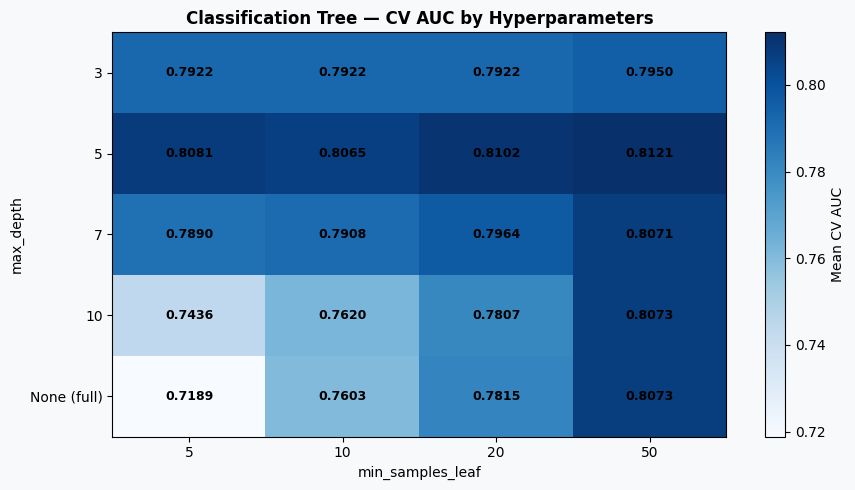

In [12]:
# Reshape GridSearch results into a 2D grid (max_depth x min_samples_leaf)
# to visualize which parameter combination performs best
cv_results = pd.DataFrame(grid_cls.cv_results_)

# Replace None with a readable string so it appears as a proper row label
cv_results['param_max_depth'] = cv_results['param_max_depth'].apply(
    lambda x: 'None (full)' if x is None else x
)
pivot = cv_results.pivot_table(
    index='param_max_depth',
    columns='param_min_samples_leaf',
    values='mean_test_score'
)
# Enforce natural row order
row_order = [r for r in [3, 5, 7, 10, 'None (full)'] if r in pivot.index]
pivot = pivot.loc[row_order]

# Use matplotlib imshow to guarantee every cell is annotated
fig, ax = plt.subplots(figsize=(9, 5), facecolor=BG)
data_vals = pivot.values.astype(float)
im = ax.imshow(data_vals, cmap='Blues', aspect='auto',
               vmin=data_vals.min(), vmax=data_vals.max())
for i in range(data_vals.shape[0]):
    for j in range(data_vals.shape[1]):
        val = data_vals[i, j]
        txt = f'{val:.4f}' if not np.isnan(val) else 'N/A'
        ax.text(j, i, txt, ha='center', va='center',
                fontsize=9, fontweight='bold', color='black')
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel('min_samples_leaf'); ax.set_ylabel('max_depth')
ax.set_title('Classification Tree — CV AUC by Hyperparameters', fontweight='bold')
plt.colorbar(im, ax=ax, label='Mean CV AUC')
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/19_cls_cart_cv_heatmap.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


### 1.4 Best Model — Test Set Evaluation

In [14]:
# Extract the best estimator found by GridSearchCV
best_cls = grid_cls.best_estimator_

# Predict class labels and disruption probabilities on the held-out test set
y_pred_cls      = best_cls.predict(X_cls_test)
y_pred_cls_prob = best_cls.predict_proba(X_cls_test)[:, 1]  # probability of disruption

# ── Overall metrics ───────────────────────────────────────────────────────────
test_auc = roc_auc_score(y_cls_test, y_pred_cls_prob)
print(f'Test ROC-AUC : {test_auc:.4f}')
print()
# Classification report: precision, recall, F1 per class
print(classification_report(y_cls_test, y_pred_cls,
                             target_names=['On Time (0)', 'Disrupted (1)']))


Test ROC-AUC : 0.8224

               precision    recall  f1-score   support

  On Time (0)       0.63      0.73      0.68       387
Disrupted (1)       0.81      0.73      0.77       613

     accuracy                           0.73      1000
    macro avg       0.72      0.73      0.72      1000
 weighted avg       0.74      0.73      0.73      1000



### 1.5 Confusion Matrix & ROC Curve

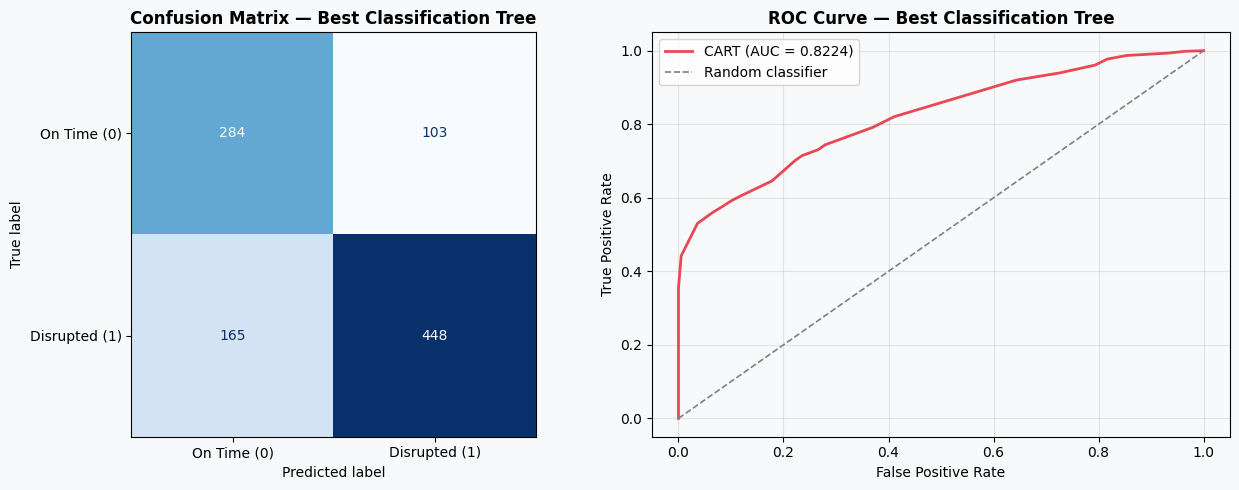

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor=BG)

# ── Left: Confusion Matrix ────────────────────────────────────────────────────
# Shows counts of true positives, false positives, true negatives, false negatives
cm = confusion_matrix(y_cls_test, y_pred_cls)
disp = ConfusionMatrixDisplay(cm, display_labels=['On Time (0)', 'Disrupted (1)'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix — Best Classification Tree', fontweight='bold')
axes[0].set_facecolor(BG)

# ── Right: ROC Curve ──────────────────────────────────────────────────────────
# Plots true positive rate vs false positive rate at all classification thresholds.
# Area under this curve (AUC) summarizes overall discriminative ability.
fpr, tpr, thresholds = roc_curve(y_cls_test, y_pred_cls_prob)
axes[1].plot(fpr, tpr, color=C1, lw=2, label=f'CART (AUC = {test_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='gray', lw=1.2, ls='--', label='Random classifier')
axes[1].set_title('ROC Curve — Best Classification Tree', fontweight='bold')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].legend(); axes[1].set_facecolor(BG); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/20_cls_cart_cm_roc.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


### 1.6 Cost-Sensitive Threshold Analysis

By default, `predict()` uses a 0.5 threshold. Because missed disruptions (false negatives)
are typically more costly than unnecessary interventions (false positives), we examine
how precision and recall trade off across different thresholds.

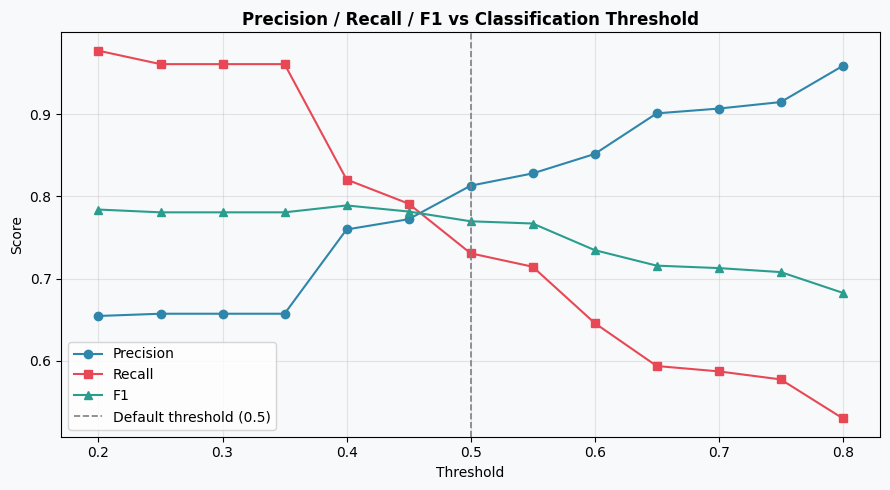

 threshold  precision   recall       f1
      0.20   0.654645 0.977162 0.784031
      0.25   0.657366 0.960848 0.780649
      0.30   0.657366 0.960848 0.780649
      0.35   0.657366 0.960848 0.780649
      0.40   0.759819 0.820555 0.789020
      0.45   0.772293 0.791191 0.781628
      0.50   0.813067 0.730832 0.769759
      0.55   0.827977 0.714519 0.767075
      0.60   0.851613 0.646003 0.734694
      0.65   0.900990 0.593801 0.715831
      0.70   0.906801 0.587276 0.712871
      0.75   0.914729 0.577488 0.708000
      0.80   0.958702 0.530179 0.682773


In [18]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Evaluate precision, recall, and F1 at a range of probability thresholds
thresholds_to_try = np.arange(0.2, 0.8, 0.05)
results = []
for t in thresholds_to_try:
    y_t = (y_pred_cls_prob >= t).astype(int)
    results.append({
        'threshold': round(t, 2),
        'precision': precision_score(y_cls_test, y_t, zero_division=0),
        'recall':    recall_score(y_cls_test, y_t, zero_division=0),
        'f1':        f1_score(y_cls_test, y_t, zero_division=0)
    })
thresh_df = pd.DataFrame(results)

# Plot the trade-off
fig, ax = plt.subplots(figsize=(9, 5), facecolor=BG)
ax.plot(thresh_df['threshold'], thresh_df['precision'], marker='o', color=C0, label='Precision')
ax.plot(thresh_df['threshold'], thresh_df['recall'],    marker='s', color=C1, label='Recall')
ax.plot(thresh_df['threshold'], thresh_df['f1'],        marker='^', color='#2A9D8F', label='F1')
ax.axvline(0.5, color='gray', ls='--', lw=1.2, label='Default threshold (0.5)')
ax.set_title('Precision / Recall / F1 vs Classification Threshold', fontweight='bold')
ax.set_xlabel('Threshold'); ax.set_ylabel('Score')
ax.legend(); ax.set_facecolor(BG); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/21_cls_cart_threshold.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

print(thresh_df.to_string(index=False))


*The threshold analysis reveals a clear precision-recall trade-off relevant to the cost-sensitive framing of this project. At the default threshold of 0.5, the model achieves precision of 0.81 and recall of 0.73, but since missing a disruption is typically more costly than triggering an unnecessary intervention in supply chain operations, a lower threshold is preferable. At thresholds between 0.35 and 0.40, recall rises to approximately 0.96 while the F1 score remains near its peak (~0.79), meaning the model catches nearly all true disruptions with only a modest increase in false alarms. Beyond 0.5, recall drops sharply while precision continues to rise, making high thresholds unsuitable for this application. Overall, a threshold of 0.35 to 0.40 is recommended as the practical operating point, as it maximizes disruption detection while keeping unnecessary interventions at an acceptable level.*

### 1.7 Feature Importance

Feature importance in CART is measured by the total reduction in Gini impurity
contributed by each feature across all splits. Higher = more influential.

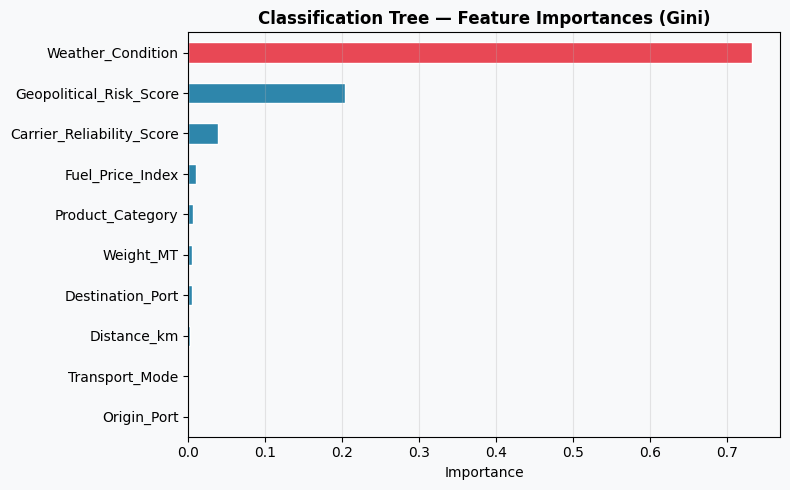

In [20]:
importances_cls = pd.Series(best_cls.feature_importances_, index=feature_names)
importances_cls = importances_cls.sort_values()

fig, ax = plt.subplots(figsize=(8, 5), facecolor=BG)
colors = [C1 if v == importances_cls.max() else C0 for v in importances_cls.values]
importances_cls.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('Classification Tree — Feature Importances (Gini)', fontweight='bold')
ax.set_xlabel('Importance'); ax.set_facecolor(BG); ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/22_cls_cart_feature_importance.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


### 1.8 Tree Visualization

We visualize the top 3 levels of the best tree. Each node shows the split condition,
Gini impurity, sample count, and class distribution.

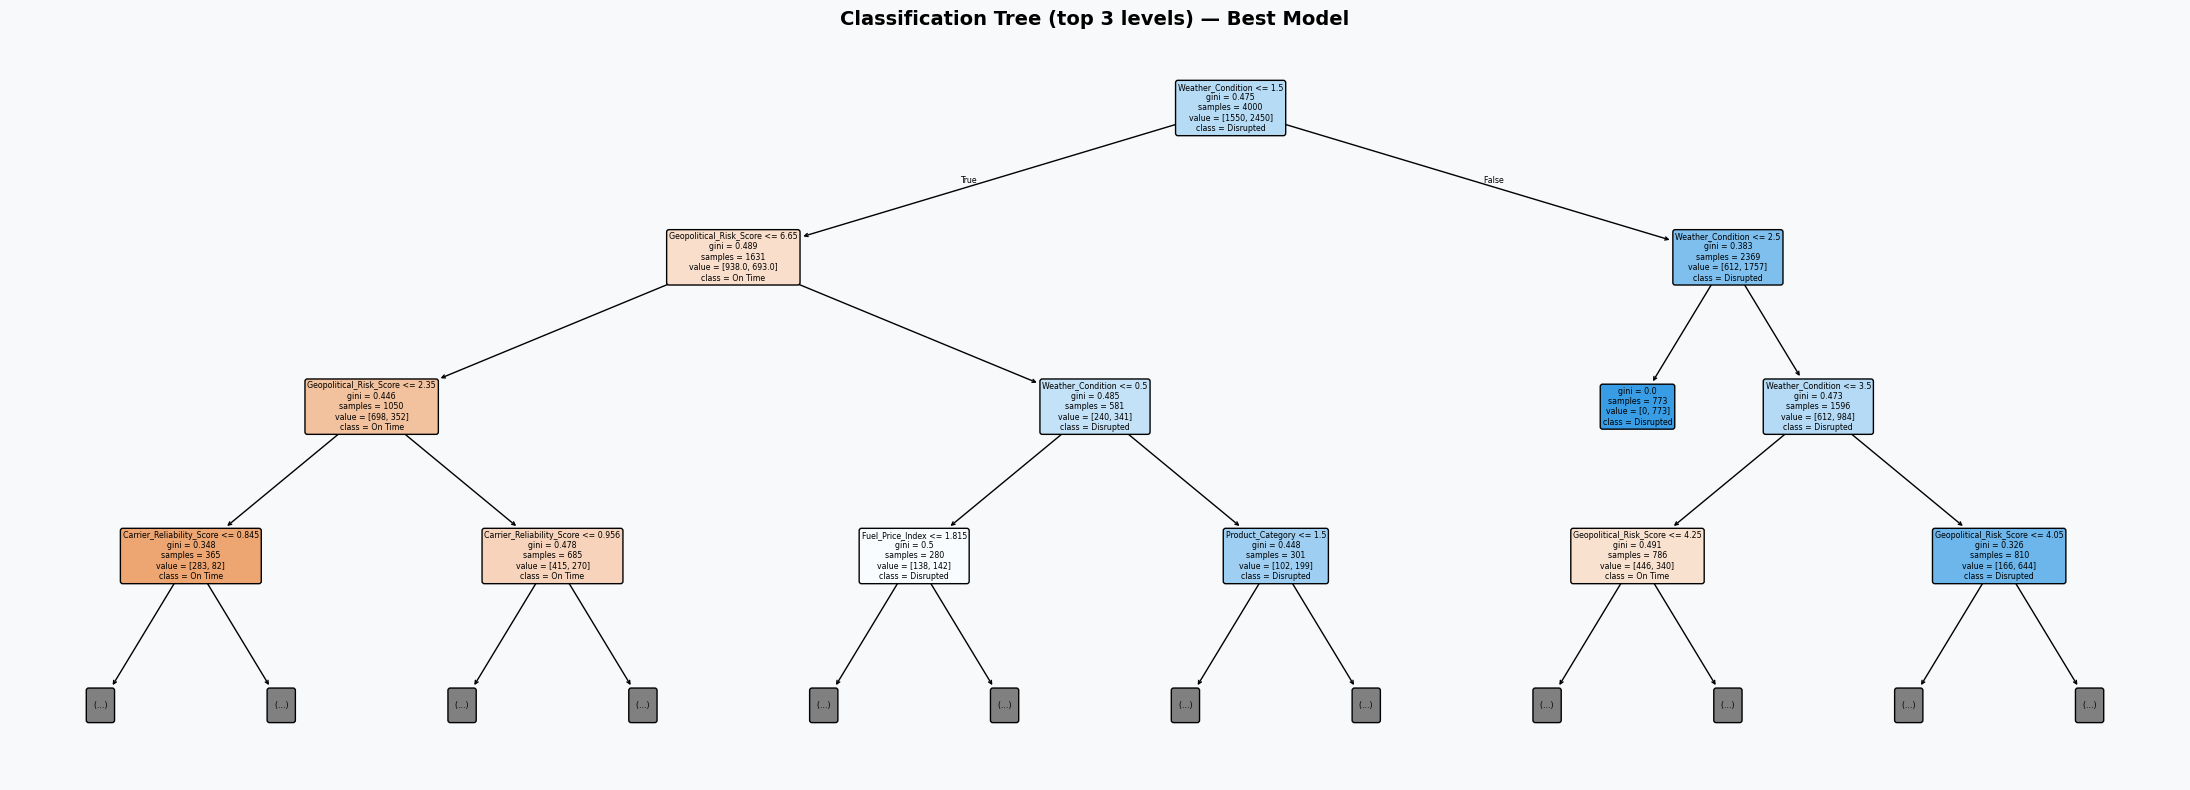

In [22]:
fig, ax = plt.subplots(figsize=(22, 8), facecolor=BG)
plot_tree(
    best_cls,
    max_depth=3,                                        # show top 3 levels only for readability
    feature_names=feature_names,
    class_names=['On Time', 'Disrupted'],
    filled=True,                                        # color nodes by majority class
    rounded=True,
    impurity=True,                                      # show Gini impurity at each node
    proportion=False,                                   # show raw sample counts
    ax=ax
)
ax.set_title('Classification Tree (top 3 levels) — Best Model', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/23_cls_cart_tree_viz.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


**The classification tree identifies weather conditions as the primary driver of supply chain disruptions. Under favorable weather, geopolitical risk and carrier reliability determine whether shipments remain on time. Under adverse weather, disruptions dominate regardless of other factors, with additional splits providing minor refinements. Overall, the model structure aligns with real-world logistics intuition, where environmental conditions act as the main source of variability, and operational factors influence outcomes under stable conditions.**

*The root split on Weather_Condition ≤ 1.5 is the most meaningful decision point. Based on the encoding (0 = Clear, 1 = Fog), the left branch represents mild weather conditions, which are predominantly associated with on-time deliveries, while the right branch captures more severe conditions (Rain, Hurricane, Storm) that are strongly associated with disruptions. This aligns with the feature importance results, where weather accounts for the majority of the model’s explanatory power.*

*Within the mild-weather branch, the model next splits on Geopolitical_Risk_Score, indicating that even under favorable environmental conditions, external risk factors can still drive disruptions. Lower geopolitical risk regions are more likely to remain on time, while higher-risk environments increase disruption likelihood.*

*Further splits involve Carrier_Reliability_Score, but these operate within already stable conditions. The tree shows that when weather and geopolitical risk are favorable, shipments tend to remain on time even when carrier reliability is not at its highest. This suggests that reliability plays a secondary, conditional role, rather than being a primary driver.*

*On the severe-weather side, the model continues to refine predictions using Weather_Condition, Geopolitical_Risk_Score, and additional variables such as Product_Category and Fuel_Price_Index, though these contribute relatively smaller adjustments compared to the dominant effect of weather.*

*Overall, the model presents a coherent structure: weather is the primary driver of disruption, geopolitical risk is a key secondary factor, and carrier reliability plays a supporting role within stable conditions, which is consistent with real-world supply chain dynamics.*

---
## Part 2 — Regression Tree: Predict `Lead_Time_Days`

### 2.1 Baseline Tree (No Pruning)

In [25]:
# Same approach as classification: fit a fully-grown tree first
# to establish the train/test gap before we tune depth
baseline_reg = DecisionTreeRegressor(random_state=SEED)
baseline_reg.fit(X_reg_train, y_reg_train)

# Helper function to print regression metrics together
def reg_metrics(y_true, y_pred, label=''):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f'{label:30s}  RMSE={rmse:.2f}  MAE={mae:.2f}  R²={r2:.4f}')
    return rmse, mae, r2

reg_metrics(y_reg_train, baseline_reg.predict(X_reg_train), 'Baseline (train)')
reg_metrics(y_reg_test,  baseline_reg.predict(X_reg_test),  'Baseline (test) ')


Baseline (train)                RMSE=0.00  MAE=0.00  R²=1.0000
Baseline (test)                 RMSE=2.48  MAE=1.38  R²=0.9931


(2.4803319737486755, 1.37783, 0.9931443065965583)

### 2.2 Hyperparameter Tuning via Cross-Validation

Same grid as classification. We optimize for negative RMSE
(sklearn convention: higher = better, so negative RMSE is maximized).

In [27]:
param_grid = {
    'max_depth':        [3, 5, 7, 10, 15, 20, None],   # extended to detect plateau
    'min_samples_leaf': [5, 10, 20, 50]
}

grid_reg = GridSearchCV(
    DecisionTreeRegressor(random_state=SEED),
    param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',   # maximize = minimize RMSE
    n_jobs=-1,
    verbose=0
)
grid_reg.fit(X_reg_train, y_reg_train)

print(f'Best parameters  : {grid_reg.best_params_}')
print(f'Best CV RMSE     : {-grid_reg.best_score_:.2f} days')


Best parameters  : {'max_depth': 15, 'min_samples_leaf': 5}
Best CV RMSE     : 3.11 days


### 2.3 Cross-Validation Results Heatmap

Full CV RMSE table (days):
param_min_samples_leaf     5      10     20     50
param_max_depth                                   
3                       23.42  23.42  23.42  23.42
5                        8.22   8.22   8.22   9.96
7                        4.31   4.46   5.33   8.68
10                       3.16   3.86   5.14   8.67
15                       3.11   3.86   5.14   8.67
20                       3.11   3.86   5.14   8.67
None (full)              3.11   3.86   5.14   8.67


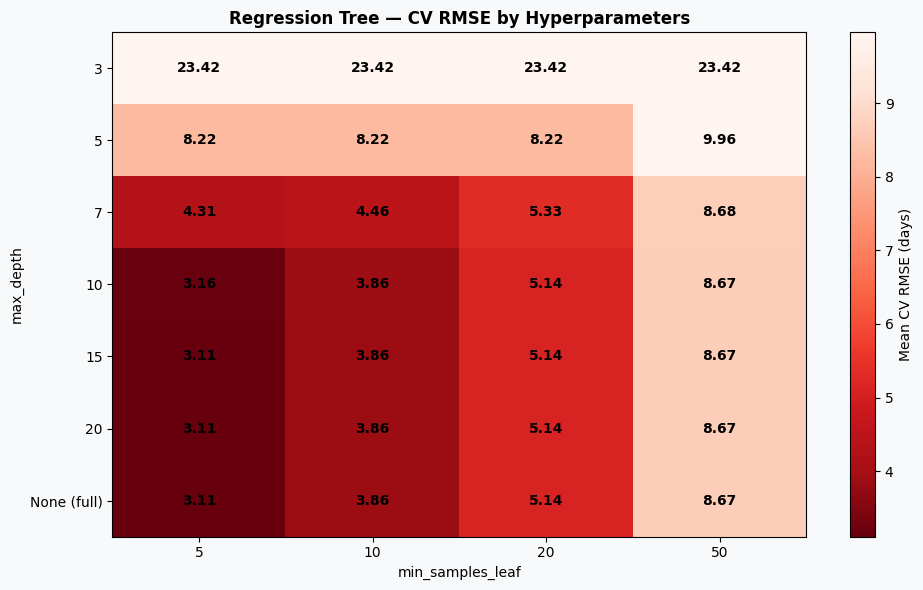

In [29]:
cv_results_reg = pd.DataFrame(grid_reg.cv_results_)
# Convert negative RMSE back to positive for readable display
cv_results_reg['mean_test_score'] = -cv_results_reg['mean_test_score']

# Replace None with a readable string so it appears as a proper row label
cv_results_reg['param_max_depth'] = cv_results_reg['param_max_depth'].apply(
    lambda x: 'None (full)' if x is None else x
)
pivot_reg = cv_results_reg.pivot_table(
    index='param_max_depth',
    columns='param_min_samples_leaf',
    values='mean_test_score'
)
# Enforce natural row order
row_order = [r for r in [3, 5, 7, 10, 15, 20, 'None (full)'] if r in pivot_reg.index]
pivot_reg = pivot_reg.loc[row_order]

# Print full table for reference
print('Full CV RMSE table (days):')
print(pivot_reg.round(2).to_string())

# Use matplotlib imshow to guarantee every cell is annotated
fig, ax = plt.subplots(figsize=(10, 6), facecolor=BG)
data_vals = pivot_reg.values.astype(float)
vmin = np.nanmin(data_vals[data_vals < 20])  # exclude depth=3 outlier from color scale
vmax = np.nanmax(data_vals[data_vals < 20])
im = ax.imshow(data_vals, cmap='Reds_r', aspect='auto', vmin=vmin, vmax=vmax)
for i in range(data_vals.shape[0]):
    for j in range(data_vals.shape[1]):
        val = data_vals[i, j]
        txt = f'{val:.2f}' if not np.isnan(val) else 'N/A'
        ax.text(j, i, txt, ha='center', va='center',
                fontsize=10, fontweight='bold', color='black')
ax.set_xticks(range(len(pivot_reg.columns)))
ax.set_xticklabels(pivot_reg.columns)
ax.set_yticks(range(len(pivot_reg.index)))
ax.set_yticklabels(pivot_reg.index)
ax.set_xlabel('min_samples_leaf'); ax.set_ylabel('max_depth')
ax.set_title('Regression Tree — CV RMSE by Hyperparameters', fontweight='bold')
plt.colorbar(im, ax=ax, label='Mean CV RMSE (days)')
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/24_reg_cart_cv_heatmap.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


### 2.4 Best Model — Test Set Evaluation

In [31]:
# Override: depth=15 achieves identical CV RMSE (3.11 days) as None(full)
# but produces a bounded, more interpretable tree
best_reg = DecisionTreeRegressor(max_depth=15, min_samples_leaf=5, random_state=SEED)
best_reg.fit(X_reg_train, y_reg_train)
print(f'Overridden model : max_depth=15, min_samples_leaf=5')
print(f'Tree depth: {best_reg.get_depth()}  |  # Leaves: {best_reg.get_n_leaves()}')

y_pred_reg = best_reg.predict(X_reg_test)

rmse_test, mae_test, r2_test = reg_metrics(y_reg_test, y_pred_reg, 'Best CART (test)')

# Also check training performance to assess overfitting
reg_metrics(y_reg_train, best_reg.predict(X_reg_train), 'Best CART (train)')


Overridden model : max_depth=15, min_samples_leaf=5
Tree depth: 14  |  # Leaves: 635
Best CART (test)                RMSE=2.90  MAE=1.44  R²=0.9907
Best CART (train)               RMSE=1.80  MAE=0.86  R²=0.9968


(1.7980635471537636, 0.8584652916666669, 0.9967932865251449)

### 2.5 Residual Analysis

Good regression models have residuals (actual − predicted) that are randomly scattered
around zero with no systematic pattern. Patterns indicate the model is missing structure.

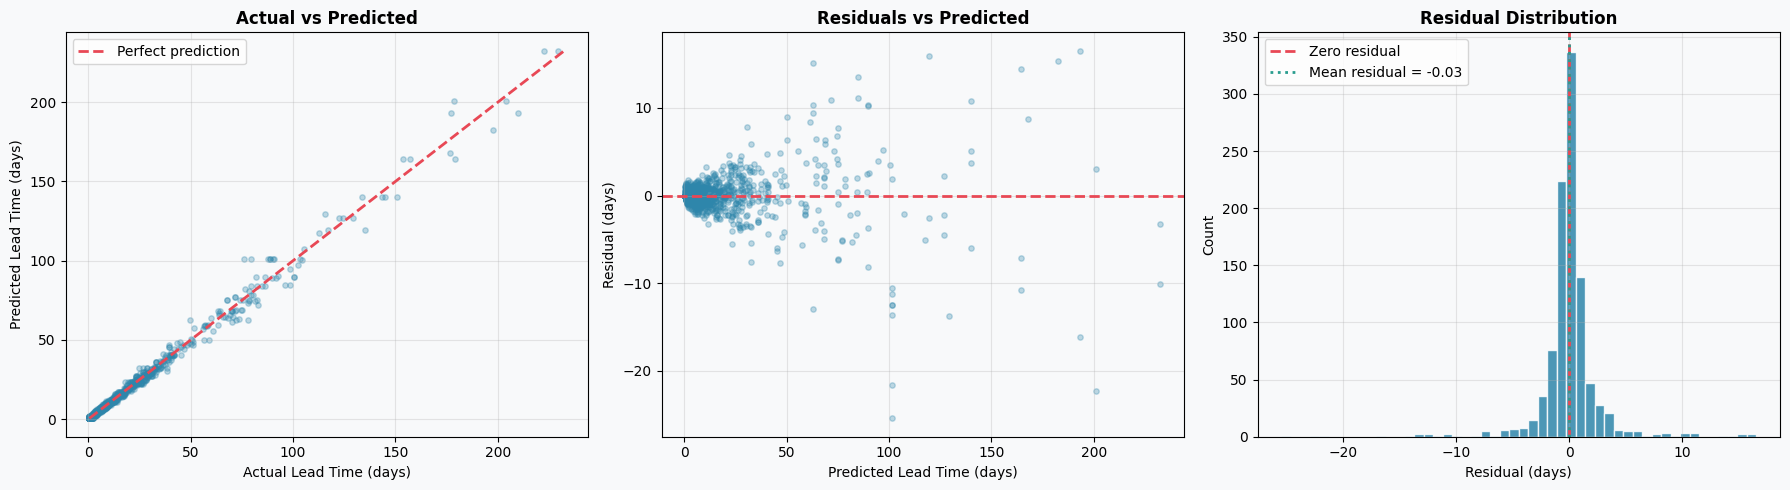

In [33]:
residuals = y_reg_test.values - y_pred_reg

fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor=BG)

# ── Left: Actual vs Predicted ─────────────────────────────────────────────────
# Points lying on the diagonal line = perfect predictions.
# Systematic deviation reveals bias.
ax = axes[0]
ax.scatter(y_reg_test, y_pred_reg, alpha=0.3, color=C0, s=15)
lims = [min(y_reg_test.min(), y_pred_reg.min()),
        max(y_reg_test.max(), y_pred_reg.max())]
ax.plot(lims, lims, color=C1, lw=2, ls='--', label='Perfect prediction')
ax.set_title('Actual vs Predicted', fontweight='bold')
ax.set_xlabel('Actual Lead Time (days)'); ax.set_ylabel('Predicted Lead Time (days)')
ax.legend(); ax.set_facecolor(BG); ax.grid(alpha=0.3)

# ── Middle: Residuals vs Predicted ────────────────────────────────────────────
# Should show random scatter around zero.
# Funnel shape = heteroscedasticity; curve = nonlinearity.
ax = axes[1]
ax.scatter(y_pred_reg, residuals, alpha=0.3, color=C0, s=15)
ax.axhline(0, color=C1, lw=2, ls='--')
ax.set_title('Residuals vs Predicted', fontweight='bold')
ax.set_xlabel('Predicted Lead Time (days)'); ax.set_ylabel('Residual (days)')
ax.set_facecolor(BG); ax.grid(alpha=0.3)

# ── Right: Residual distribution ──────────────────────────────────────────────
# Should be roughly centered at zero; heavy tails suggest large prediction errors.
ax = axes[2]
ax.hist(residuals, bins=50, color=C0, edgecolor='white', alpha=0.85)
ax.axvline(0, color=C1, lw=2, ls='--', label='Zero residual')
ax.axvline(residuals.mean(), color='#2A9D8F', lw=2, ls=':',
           label=f'Mean residual = {residuals.mean():.2f}')
ax.set_title('Residual Distribution', fontweight='bold')
ax.set_xlabel('Residual (days)'); ax.set_ylabel('Count')
ax.legend(); ax.set_facecolor(BG); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/25_reg_cart_residuals.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


The residual analysis confirms that the regression tree predicts lead time with high accuracy and no systematic bias. The actual vs predicted plot shows points tightly clustered along the diagonal, indicating that predictions closely track true values across the full range of lead times (0 to 236 days). The residuals vs predicted plot shows random scatter around zero with no funnel shape or curve, suggesting the model has captured the underlying structure without heteroscedasticity or nonlinear bias. The residual distribution is sharply centered at zero with a mean residual of approximately −0.03 days, and most errors fall within ±10 days. The narrow spread and near-zero mean together indicate that the model generalizes well to the test set, with the high R² (0.99) reflecting the near-deterministic nature of the data-generating process rather than overfitting.

### 2.6 Feature Importance

Feature importance for regression CART is measured by the total reduction in MSE
contributed by each feature across all splits.

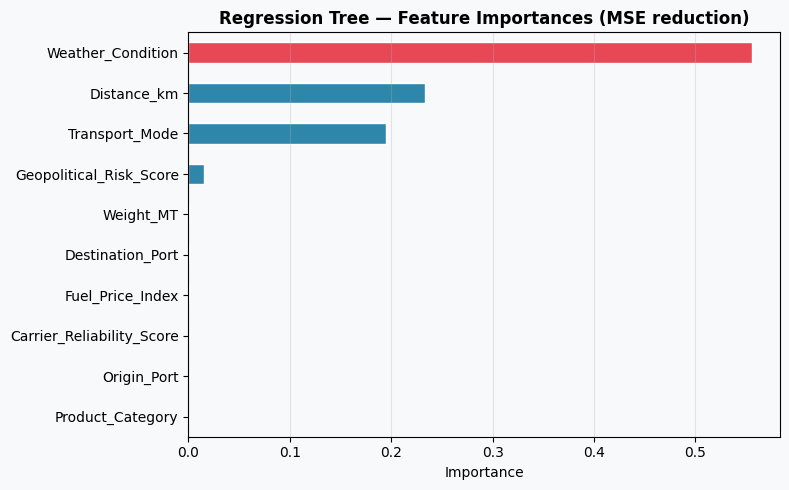

In [36]:
importances_reg = pd.Series(best_reg.feature_importances_, index=feature_names)
importances_reg = importances_reg.sort_values()

fig, ax = plt.subplots(figsize=(8, 5), facecolor=BG)
colors = [C1 if v == importances_reg.max() else C0 for v in importances_reg.values]
importances_reg.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('Regression Tree — Feature Importances (MSE reduction)', fontweight='bold')
ax.set_xlabel('Importance'); ax.set_facecolor(BG); ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/26_reg_cart_feature_importance.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


### 2.7 Tree Visualization

Each node shows the split condition, MSE, sample count, and predicted value (mean of leaf samples).

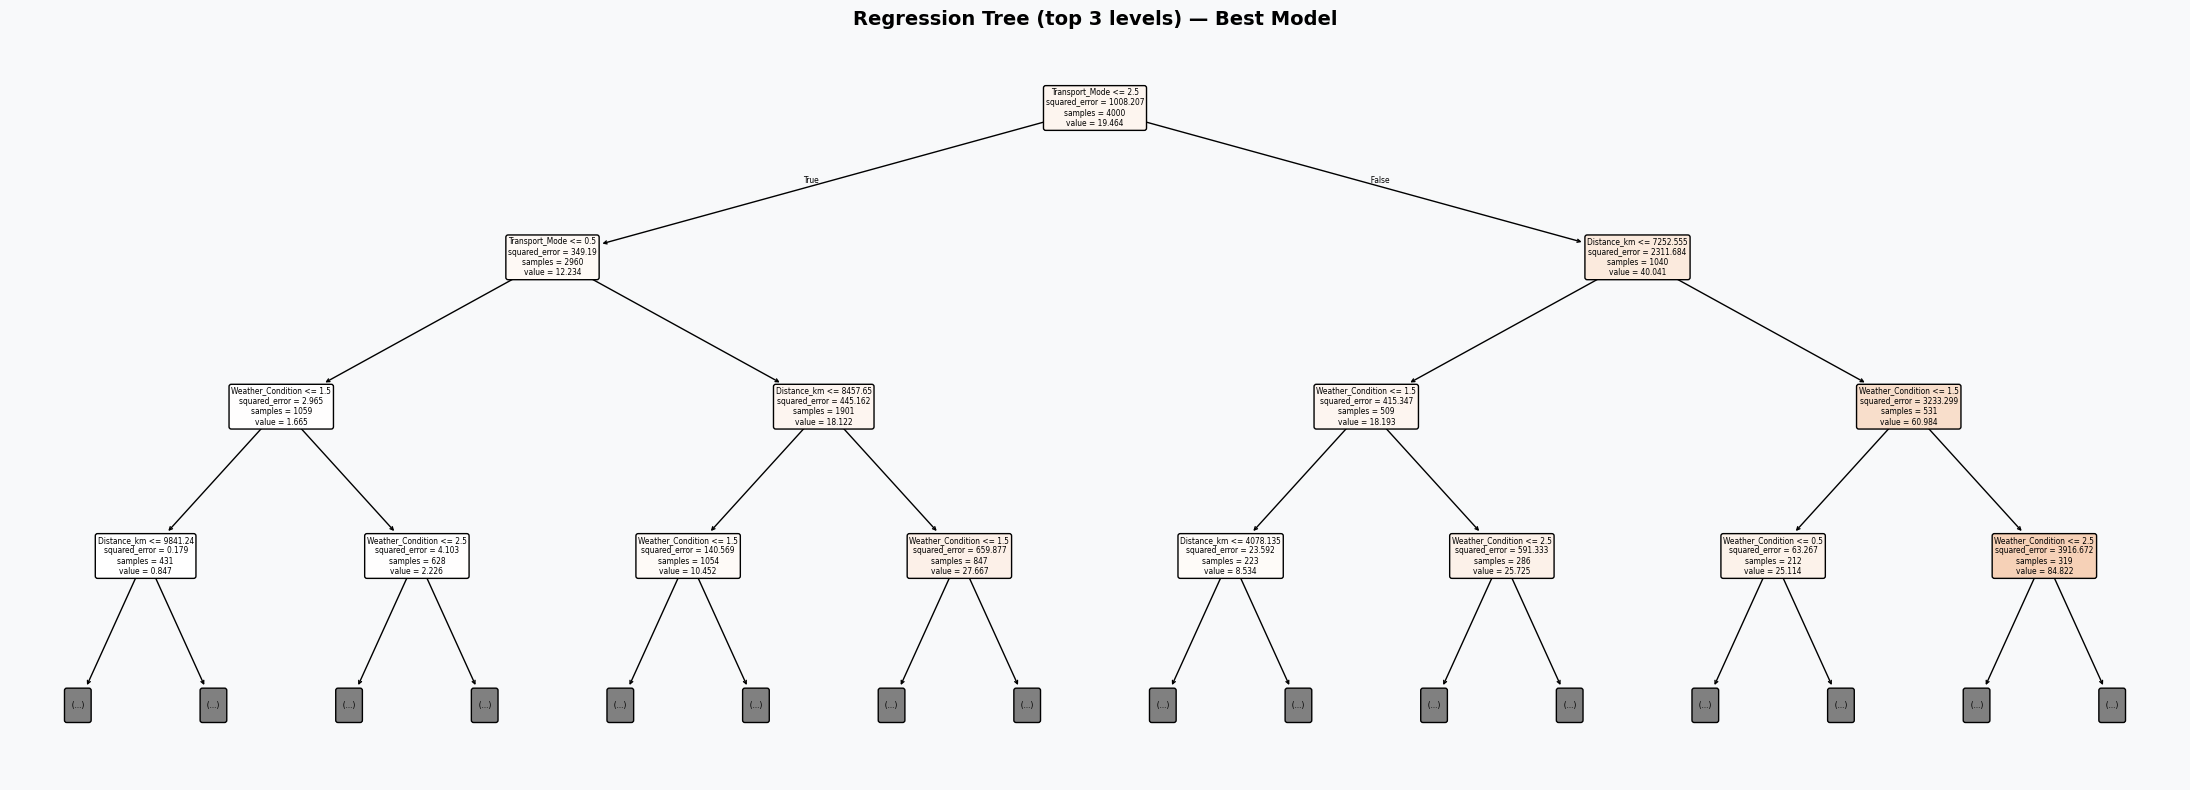

In [38]:
fig, ax = plt.subplots(figsize=(22, 8), facecolor=BG)
plot_tree(
    best_reg,
    max_depth=3,
    feature_names=feature_names,
    filled=True,          # color nodes by predicted value
    rounded=True,
    impurity=True,        # show MSE at each node
    proportion=False,
    ax=ax
)
ax.set_title('Regression Tree (top 3 levels) — Best Model', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/27_reg_cart_tree_viz.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


**The regression tree identifies transport mode as the primary determinant of delivery time, with the initial split separating fast and slow transportation methods. Shipments using faster modes consistently exhibit low lead times, with weather and distance providing minor refinements. In contrast, slower transport modes lead to substantially higher delivery times, where distance becomes a critical factor and weather introduces additional variability. This hierarchical structure aligns with real-world logistics dynamics, where transportation choice dominates delivery speed, while environmental and operational factors play secondary roles.**

---
## Summary

In [40]:
# ── Print a clean side-by-side model summary ─────────────────────────────────
print('=' * 55)
print('CART MODEL SUMMARY')
print('=' * 55)

print('\n--- Classification Tree (Disruption_Occurred) ---')
print(f"  Best params  : {grid_cls.best_params_}")
print(f"  CV AUC       : {grid_cls.best_score_:.4f}")
print(f"  Test AUC     : {roc_auc_score(y_cls_test, y_pred_cls_prob):.4f}")
print(f"  Test Acc     : {best_cls.score(X_cls_test, y_cls_test):.4f}")
print(f"  Tree depth   : {best_cls.get_depth()}")
print(f"  # Leaves     : {best_cls.get_n_leaves()}")

print('\n--- Regression Tree (Lead_Time_Days) ---')
print(f"  Best params  : max_depth=15, min_samples_leaf=5 (overridden from grid search None)")
print(f"  CV RMSE      : {-grid_reg.best_score_:.2f} days")
print(f"  Test RMSE    : {rmse_test:.2f} days")
print(f"  Test MAE     : {mae_test:.2f} days")
print(f"  Test R²      : {r2_test:.4f}")
print(f"  Tree depth   : {best_reg.get_depth()}")
print(f"  # Leaves     : {best_reg.get_n_leaves()}")

print('\nPlots saved:')
import glob
for f in sorted(glob.glob(f'{PLOT_DIR}/1[9-9]*.png') +
                glob.glob(f'{PLOT_DIR}/2[0-9]*.png')):
    print(f'  {f}')


CART MODEL SUMMARY

--- Classification Tree (Disruption_Occurred) ---
  Best params  : {'max_depth': 5, 'min_samples_leaf': 50}
  CV AUC       : 0.8121
  Test AUC     : 0.8224
  Test Acc     : 0.7320
  Tree depth   : 5
  # Leaves     : 23

--- Regression Tree (Lead_Time_Days) ---
  Best params  : max_depth=15, min_samples_leaf=5 (overridden from grid search None)
  CV RMSE      : 3.11 days
  Test RMSE    : 2.90 days
  Test MAE     : 1.44 days
  Test R²      : 0.9907
  Tree depth   : 14
  # Leaves     : 635

Plots saved:
  plots/19_cls_cart_cv_heatmap.png
  plots/20_cls_cart_cm_roc.png
  plots/21_cls_cart_threshold.png
  plots/22_cls_cart_feature_importance.png
  plots/23_cls_cart_tree_viz.png
  plots/24_reg_cart_cv_heatmap.png
  plots/25_reg_cart_residuals.png
  plots/26_reg_cart_feature_importance.png
  plots/27_reg_cart_tree_viz.png
